In [1]:
import numpy as np
import pandas as pd
import random

import tensorflow as tf
import tensorflow_datasets as tfds
from tensorflow.keras.preprocessing.image import ImageDataGenerator, array_to_img, img_to_array, load_img

import os
import shutil
import pathlib
from tqdm import tqdm

import warnings
warnings.filterwarnings("ignore", category=UserWarning) #used to supress the tf version warning. 

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn import ensemble
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import GridSearchCV
from scipy.stats import randint
from sklearn.preprocessing import LabelEncoder

DATA_PATH = "/home/pri/Development/dsci207/coral_images" # replace with your path

2026-03-01 21:51:24.646819: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-03-01 21:51:24.647146: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-01 21:51:24.712436: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-01 21:51:25.894966: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off,

#### Workflow for EDA and Data pre-processing
Load -> Resize -> clean Normalize -> Encode -> EDA.

While loading the images, I got the error : ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (923,) + inhomogeneous part.<br>
This happened because likely, the image resolutions were different shapes. NumPy can only create a single ndarray if all elements have identical shape, otherwise Numpy cannot stack them. We need to resize every image to the same size, the sandard size is 224x224. <br>
Also, Neural Networks like CNN require fixed input sizes (batch_size, height, width, channels) so they can be stacked into 1 tensor.

Optional approach - for ML Projects which is like a better practice: 

Instead of manually loading images, we can use:

TensorFlow ImageDataGenerator
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

train_data = datagen.flow_from_directory(
    DATA_PATH,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    subset='training'
)

This does the following:
- Resizes automatically
- Normalizes automatically
- Handles batching
- Prevents memory overload

We can also pad or crop images or use adaptive pooling layers, but that is a more advanced approach.

In [2]:
# load and inspect first few images
def inspect_images(data_path, num_images=5):
    label_folders = sorted(os.listdir(data_path))
    
    for label in label_folders:
        label_path = os.path.join(data_path, label)
        
        if not os.path.isdir(label_path):
            continue
        
        print(f"\n Folder: {label}")
        print("-" * 40)
        
        image_files = os.listdir(label_path)[:num_images]
        
        for file_name in image_files:
            file_path = os.path.join(label_path, file_name)
            
            if not os.path.isfile(file_path):
                continue
            
            try:
                img = load_img(file_path)  
                img_array = img_to_array(img)
                
                print(f"File: {file_name}")
                print(f"  PIL size (width, height): {img.size}")
                print(f"  Array shape: {img_array.shape}")
                print(f"  Dtype: {img_array.dtype}")
                print()
               
            except Exception as e:
                print(f"Error loading {file_name}: {e}")

# Run inspection
inspect_images(DATA_PATH, num_images=5)


 Folder: bleached_corals
----------------------------------------
File: 14976247152_2312ebb047_b.jpg
  PIL size (width, height): (300, 200)
  Array shape: (200, 300, 3)
  Dtype: float32

File: 36347843096_b16b5f1119_o.jpg
  PIL size (width, height): (300, 169)
  Array shape: (169, 300, 3)
  Dtype: float32

File: 14101776356_d4d9038de3_b.jpg
  PIL size (width, height): (300, 200)
  Array shape: (200, 300, 3)
  Dtype: float32

File: 5398026532_570237c1ef_o.jpg
  PIL size (width, height): (300, 221)
  Array shape: (221, 300, 3)
  Dtype: float32

File: 5974390808_bc0956c2f7_b.jpg
  PIL size (width, height): (300, 200)
  Array shape: (200, 300, 3)
  Dtype: float32


 Folder: healthy_corals
----------------------------------------
File: 26641775299_53ec3af24a_o.jpg
  PIL size (width, height): (300, 225)
  Array shape: (225, 300, 3)
  Dtype: float32

File: 9329967925_dd6a659991_o.jpg
  PIL size (width, height): (300, 225)
  Array shape: (225, 300, 3)
  Dtype: float32

File: 14226066883_218d2

#### We can see from the output that the images have different shapes, so these need to be resized while loading the dataset.

In [3]:
# Load the image dataset
def load_data(path_to_data):
    '''Load 2D images and their corresponding labels
    Parameters:
    path_to_data (str): This is the path to data
    Returns:
    images (np.ndarray): A numpy array of shape (N, 224, 224, 3)
    labels (np.ndarray): A numpy array of shape (N)
    '''
    ## load images and labels
    images = []
    labels = []

    label_names = sorted(os.listdir(path_to_data)) # label folders

    for label_name in label_names:
        label_folder = os.path.join(path_to_data, label_name)

        if not os.path.isdir(label_folder): # skip the non image folder.
            continue

        for file_name in os.listdir(label_folder): # loop through images in each folder
            file_path = os.path.join(label_folder, file_name)

            if not os.path.isfile(file_path): # skip non-image files just in case
                continue

            try:
                image = load_img(file_path, target_size=(224, 224)) # resize while loading image
                image_array = img_to_array(image) # convert image to np array
                images.append(image_array)
                labels.append(label_name)
            except Exception as e:
                print(f"Skipping {file_path}: {e}")
    
    return np.array(images), np.array(labels) # return np arrays

In [4]:
# Load images and labels. Print shapes
images, labels = load_data(DATA_PATH)

print("Shape of images ", images.shape)
print("Shape of labels ", labels.shape)
print("Unique labels:", np.unique(labels))

Shape of images  (923, 224, 224, 3)
Shape of labels  (923,)
Unique labels: ['bleached_corals' 'healthy_corals']


#### Plot the class distribution and first 5 images from each class
There are only 2 classes bleached_corals and healthy_corals. There is mild class imbalance which would not impact the model performance as the model cannot learn patterns or overpredict the dominant class.

/tmp/ipykernel_23027/2014155664.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=label_counts.index, y=label_counts.values, palette="viridis")


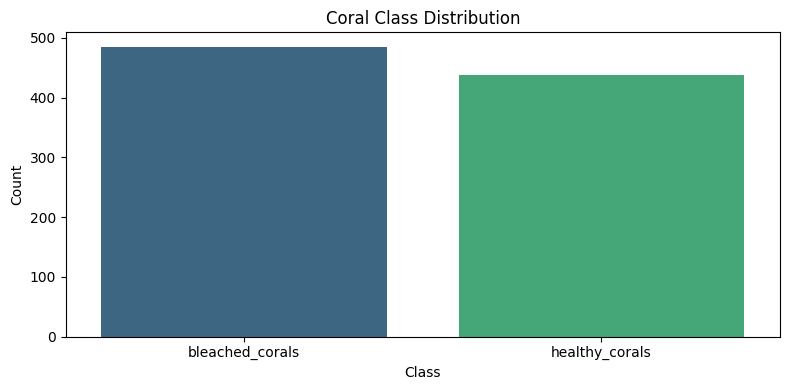

In [6]:
label_counts = pd.Series(labels).value_counts().sort_index()

plt.figure(figsize=(8, 4))

sns.barplot(x=label_counts.index, y=label_counts.values, palette="viridis")

plt.title("Coral Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.xticks()

plt.tight_layout()
plt.show()

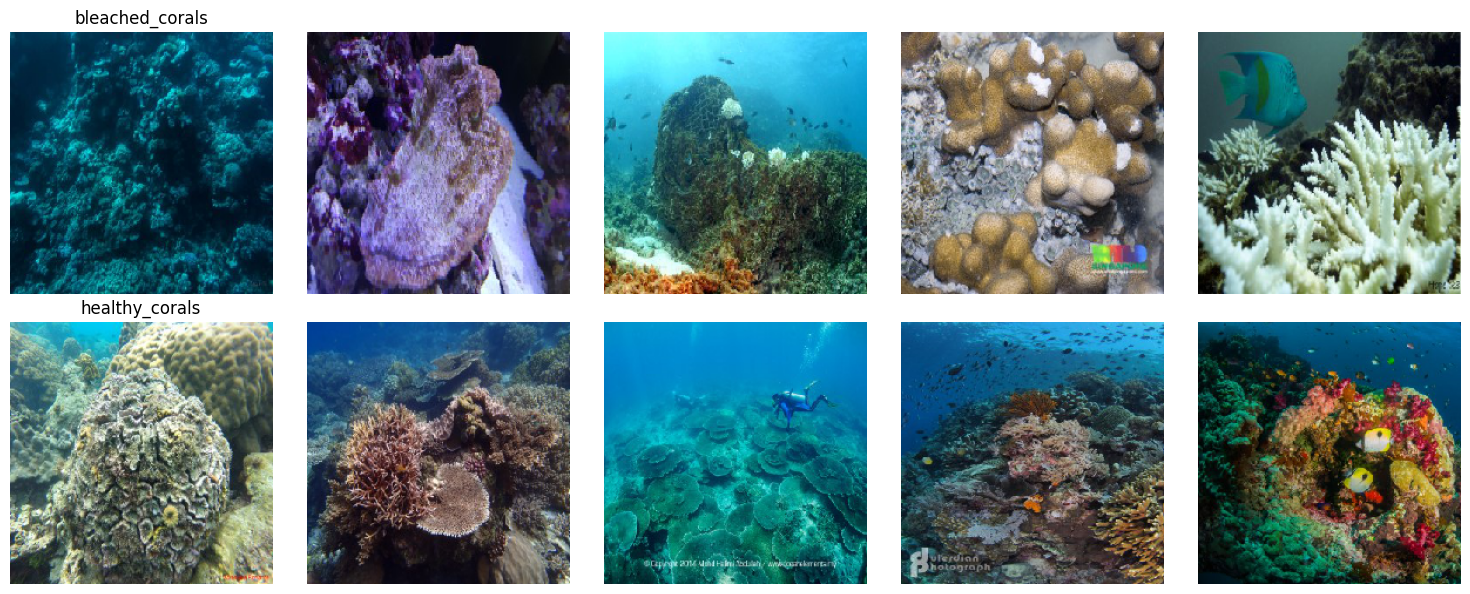

In [7]:
# Unique class names
unique_classes = np.unique(labels)

# 1. Print first 5 images from each class
image_list = []
for class_name in unique_classes:
    indices = np.where(labels == class_name)[0] # array of indices for the first class
    first_five_indices = indices[:5] # array of pixels 224x224x3 for the first 5 images
    for idx in first_five_indices:
        image_list.append((class_name, images[idx]))

# Total number of classes
num_classes = len(unique_classes)
num_images_per_class = 5

# Create subplot grid 
fig, axes = plt.subplots(num_classes, num_images_per_class, 
                         figsize=(15, 3 * num_classes))

# Plot 5 images in 2 rows    

for row, class_name in enumerate(unique_classes):
    indices = np.where(labels == class_name)[0][:5]
    
    for col, idx in enumerate(indices):
        ax = axes[row, col]
        ax.imshow(images[idx].astype("uint8"))
        ax.set_title(class_name if col == 0 else "")
        ax.axis("off")

plt.tight_layout()
plt.show()

#### Workflow for different Algorithms:
1. Classical ML - (Logistic Regression, KNN, Random Forest, XG Boost)
- 1. shuffle
- 2. normalize images /255
- 3. flatten
- 4. encode labels
- 5. train-test split (ship shuffle if using sklearn train_test_split)
- 6. train model

2. CNN / Deep Learning
- 1. Shuffle (optional if splitting with sklearn)
- 2. train-test split
- 3. normalize images /255
- 4. DO NOT FLATTEN - skip this step
- 5. encode labels
- 6. Build CNN

In [8]:
# Step 0 Create a copy of dataset for classical ML
images_ml = images.copy()
labels_ml = labels.copy()

# Step 1. Normalize (skip shuffle as we will use train test split)
def preprocess_images(images):
    return images / 255.0

# Step 2. Flatten
def flatten_images(images):
    """ Flattens images from (N, H, W, C) to (N, H*W*C)
    """
    N = images.shape[0]
    return images.reshape(N, -1)

# Step 3. Encode Labels

def encode_labels(labels):
    le = LabelEncoder()
    encoded = le.fit_transform(labels)
    return encoded, le

In [9]:
encoded_labels, label_encoder = encode_labels(labels)

In [10]:
def split_image_data(images, labels, train_size=0.6, val_size=0.2, test_size=0.2, random_state=42):
    """
    Splits image dataset into train, validation, and test sets.
        Returns: X_train, y_train, X_val, y_val, X_test, y_test
    """
    # create data splits
    # no need of manual shuffling if using train_test_split.
    X_main, X_test, y_main, y_test = train_test_split(
        images,
        labels,
        test_size=test_size,
        random_state=random_state,
        stratify=labels
    )
    
    # Compute validation ratio relative to remaining data
    val_relative_size = val_size / (train_size + val_size)
    
    # Second split: train vs val
    X_train, X_val, y_train, y_val = train_test_split(
        X_main,
        y_main,
        test_size=val_relative_size,
        random_state=random_state,
        stratify=y_main
    )
    
    return X_train, y_train, X_val, y_val, X_test, y_test

In [11]:
X_train, y_train, X_val, y_val, X_test, y_test = split_image_data(
    images,
    labels,
    train_size=0.6,
    val_size=0.2,
    test_size=0.2,
    random_state=42
)

print("Train images shape:", X_train.shape)
print("Train labels shape:", y_train.shape)

print("Validation images shape:", X_val.shape)
print("Validation labels shape:", y_val.shape)

print("Test images shape:", X_test.shape)
print("Test labels shape:", y_test.shape)

Train images shape: (553, 224, 224, 3)
Train labels shape: (553,)
Validation images shape: (185, 224, 224, 3)
Validation labels shape: (185,)
Test images shape: (185, 224, 224, 3)
Test labels shape: (185,)
